# Examen Práctico

#### 01-3900 | Ciencia de datos | 2025

**Fecha de Entrega: 29/10/2025**

**Grupo:** Pura Data

**Integrantes:**

*   Costanzo, Marcos Ezequiel - DNI: 40.955.907
*   Fernandez, Rocio Belen - DNI: 43.875.244
*   Quelali Amistoy, Marcos Emir - DNI: 36.360.020
*   Sandoval Vasquez, Juan Leandro - DNI: 41.548.235
*   Siculin, Luciano Nahuel - DNI:

**Alumno:** COMPLETAR CON EL NOMBRE DE CADA UNO EN LA ENTREGA FINAL

## Objetivos

* Desarrollar hipótesis sobre conjunto de datos utilizando técnicas de análisis exploratorio.
* Comprender los algoritmos utilizados en Machine Learning para problemas de clasificación.
* Desarrollar modelos predictivos para resolver problemas en el ámbito de la ciencia de datos.
* Comunicar los resultados del análisis de datos, a través de técnicas de visualización de información adecuadas e interpretables.

## Caso Propuesto

La empresa "Business Prop SRL" contrata nuestros servicios para que le desarrollemos un modelo que permita predecir si los departamentos vendidos pagan o no comisión, cuando su precio de venta sea superior a un determinado valor.  

Para ello, nos comparten un dataset llamado dptos_entrenamiento.csv, que contiene información de departamentos vendidos en distintos lugares de Argentina y el exterior. Este dataset será el que utilicemos para el entrenamiento del modelo construido.  

El dataset de predicción a utilizar es dptos_predecir.csv, el cual no contiene la etiqueta de la variable clase (por defecto viene indicada como “no paga”). Cada uno de estos datasets pueden descargarlos desde:

* [Departamentos Entrenamiento](https://raw.githubusercontent.com/pokengineer/DataScience/refs/heads/main/assessment/dptos_entrenamiento.csv)
* [Departamentos Predicción](https://raw.githubusercontent.com/pokengineer/DataScience/refs/heads/main/assessment/dptos_predecir.csv)

### a. Función de ganancia y criterio de aprobación

Por cada predicción que el modelo acierte, la empresa les pagará USD 100 en concepto de comisión, pero si fallan y cobran una comisión que no deberían, deben darle a Business Prop SRL una compensación de USD 50.

La evaluación de aprendizaje se considerará aprobada si la ganancia obtenida por el modelo sobre los datos desconocidos supera los USD 300.000. Como referencia, la ganancia que calculará el modelo construido es sobre el porcentaje de los datos usados para testing (muestra del 30%), con lo que ese valor puede ser alrededor de USD 120.000.

### b. Entregable

Generar y enviar un archivo de salida dptos_entrega.csv con los casos donde la medición realizada infiera que se pagará comisión. Para ello, deberá utilizar el dataset que se usó para predecir dptos_predecir.csv. Enviar también el notebook construido con el trabajo desarrollado.

### c. Sugerencias

• Algunas variables pueden generar alta dimensionalidad en el dataset, como ser los campos "title", "start_date", "end_date", "created_on", "l3", "l4" y "l5". Sugerimos comenzar con un modelo que no incluya estos campos o bien analizar qué información interesante de los mismos podría contribuir a la mejorar de la predicción. Por otro lado, sugerimos que el campo "id" lo usen como índice, con el comando set_index("id").

• Probar diferentes modelos. El objetivo del trabajo es lograr mejorar su modelo original.

# Desarrollo

## Imports necesarios

In [85]:
# Carga y manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelado con Sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import auc, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer

# Imbalanced-learn
from imblearn.over_sampling import RandomOverSampler

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Configuración de Warnings
import warnings
warnings.filterwarnings('ignore')

# Cache
from tempfile import mkdtemp
import shutil

## 1) Analisis Exploratorio

Vamos a comenzar realizando un analisis exploratorio inicial del dataset para conocer la informacion con la que cuenta, los tipos de datos que posee, la existencia de valores nulos, la relacion entre las variables y la distribucion de la variable target.

### Departamentos Entrenamiento

#### a) Cargamos el dataset en un DataFrame

In [86]:
df_train = pd.read_csv('dptos_entrenamiento.csv')
df_train = df_train.set_index('id')
df_train.head()

,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price_period,title,paga_comision
id,,,,,,,,,,,,,,,,,,,,
RDfa+E7upD0n5pptEfHdMg==,Propiedad,2020-01-08,2020-01-11,2020-01-08,-37.999860,-57.555031,Argentina,Buenos Aires Costa Atlántica,Mar del Plata,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,Venta depto dos ambientes con frente abierto,no paga
mL0EoZeEqENVokwugUrtow==,Propiedad,2020-01-17,2020-01-21,2020-01-17,-34.566363,-58.438766,Argentina,Capital Federal,Palermo,NaN,NaN,NaN,4.0,3.0,1.0,81.0,75.0,NaN,VENTA 4 AMBIENTES C COCHERA FIJA MUY LUMINOSO,paga
hOZOY5Bo9FzB3IR8V6TtiA==,Propiedad,2019-11-15,9999-12-31,2019-11-15,-37.106865,-56.862300,Argentina,Buenos Aires Costa Atlántica,Pinamar,NaN,NaN,NaN,1.0,NaN,1.0,30.0,30.0,NaN,Monoambiente con entrepiso-A 150 mts de Av- Shaw-,no paga
JKfw+/BUerJ7cNjors3UBQ==,Propiedad,2019-07-14,9999-12-31,2019-07-14,NaN,NaN,Uruguay,Montevideo,NaN,NaN,NaN,NaN,3.0,2.0,1.0,62.0,54.0,Mensual,DEPARTAMENTO EN VENTA,no paga
SBDKF7R+J2C+n4gWm4JrOw==,Propiedad,2020-02-10,2020-04-28,2020-02-10,NaN,NaN,Argentina,Bs.As. G.B.A. Zona Norte,General San Martín,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,Departamento 3 ambientes a estrenar. Oportunid...,no paga


#### b) Información general del dataset

In [87]:
display(df_train.describe(include='all'))

,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price_period,title,paga_comision
count,76984,76984,76984,76984,67643.000000,67498.000000,76984,76984,72486,14777,159,0.0,59968.000000,38049.000000,71826.000000,43049.000000,45717.000000,25755,76984,76984
unique,1,363,257,363,NaN,NaN,4,31,294,286,12,NaN,NaN,NaN,NaN,NaN,NaN,1,47234,2
top,Propiedad,2020-01-08,9999-12-31,2020-01-08,NaN,NaN,Argentina,Capital Federal,Mar del Plata,Nordelta,BarrioPortezuelo,NaN,NaN,NaN,NaN,NaN,NaN,Mensual,DEPARTAMENTO EN VENTA,no paga
freq,76984,2960,29793,2960,NaN,NaN,74447,32608,9735,1062,65,NaN,NaN,NaN,NaN,NaN,NaN,25755,799,68212
mean,NaN,NaN,NaN,NaN,-34.774702,-58.833661,NaN,NaN,NaN,NaN,NaN,NaN,2.484242,1.669637,1.386796,90.580757,81.368856,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,2.900237,2.112804,NaN,NaN,NaN,NaN,NaN,NaN,1.170088,1.910154,0.712066,459.833271,845.081843,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-54.812682,-111.611617,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,-34.748868,-58.552874,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,1.000000,43.000000,40.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,-34.603771,-58.437044,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,1.000000,60.000000,53.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,-34.558653,-58.363745,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,2.000000,2.000000,89.000000,78.000000,NaN,NaN,NaN


In [88]:
df_train.shape

(76984, 20)

El dataset cuenta con:

* 76984 registros (departamentos vendidos)
* 21 columnas de las cuales:
  * 20 corresponden a variables predictoras (información del departamento)
  * 1 columna target (con el resultado de si el departamento vendido paga o no comisión, cuando su precio de venta sea superior a un determinado valor)

In [89]:
df_train.columns

Index(['ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l1',
       'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'price_period', 'title',
       'paga_comision'],
      dtype='object')

##### Descripción del Dataset

La información que se posee sobre el departamento es la siguiente

###### Campos generales:

*   `id`: Identificador del aviso
*   `ad_type`: Tipo de Propiedad
*   `start_date`: Fecha de alta del aviso
*   `end_date`: Fecha de baja del aviso
*   `created_on`: Fecha de alta de la primera versión del aviso

###### Campos referidos a la ubicación de la propiedad o del desarrollo

*   `lat`: Latitud
*   `lon`: Longitud
*   `l1`: País
*   `l2`: Región, zona o provincia
*   `l3`: Ciudad
*   `l4`: Barrio
*   `l5`: Sub-barrio
*   `l6`: Catastro

###### Campos relativos a la propiedad

*   `rooms`: Cantidad de ambientes
*   `bedrooms`: Cantidad de dormitorios
*   `bathrooms`: Cantidad de baños
*   `surface_total`: Superficie Total en m^2
*   `surface_covered`: Superficie Cubierta en m^2
*   `price_period`: Periodo de Precio (Diario, Semanal, Mensual)
*   `title`: Titulo del anuncio

**Variable Target:** Indica si la propiedad paga o no comisión (`paga_comision`)

In [90]:
df_train.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lat                float64
lon                float64
l1                  object
l2                  object
l3                  object
l4                  object
l5                  object
l6                 float64
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
price_period        object
title               object
paga_comision       object
dtype: object

Las columnas `ad_type`, `start_date`, `end_date`, `created_on`, `l1 - l6`, `price_period`, `title` y `paga_comision` son de tipo de dato objeto.

**A futuro, tendremos que realizar un encoding que mapee los valores de estas variables a valores numéricos para poder utilizarlas (si es que las vamos a necesitar) en algunos modelos de clasificación.**

In [91]:
df_train.isna().sum() / df_train.shape[0] * 100

ad_type              0.000000
start_date           0.000000
end_date             0.000000
created_on           0.000000
lat                 12.133690
lon                 12.322041
l1                   0.000000
l2                   0.000000
l3                   5.842773
l4                  80.805102
l5                  99.793464
l6                 100.000000
rooms               22.103294
bedrooms            50.575444
bathrooms            6.700094
surface_total       44.080588
surface_covered     40.614933
price_period        66.544996
title                0.000000
paga_comision        0.000000
dtype: float64

In [92]:
df_train.isnull().sum()

ad_type                0
start_date             0
end_date               0
created_on             0
lat                 9341
lon                 9486
l1                     0
l2                     0
l3                  4498
l4                 62207
l5                 76825
l6                 76984
rooms              17016
bedrooms           38935
bathrooms           5158
surface_total      33935
surface_covered    31267
price_period       51229
title                  0
paga_comision          0
dtype: int64

Las columnas `lat`, `lon`, `l3`, `l4`, `l5`, `l6`, `rooms`, `bedrooms`, `bathrooms`, `surface_total`, `surface_covered` y `price_period` poseen valores nulos.

**A futuro, habrá que realizar una imputación de sus valores nulos si es que vamos a querer utilizarlas (dependiendo de la decisión que tomemos) en algunos modelos de clasificación.**

In [93]:
df_train.duplicated().sum()

np.int64(3510)

El dataset no cuenta con registros duplicados.

#### c) Análisis de la variable target

In [94]:
total = len(df_train)
pagos = (df_train['paga_comision'] == 'paga').sum()
no_pagos = (df_train['paga_comision'] == 'no paga').sum()

porcentaje_departamentos_pagos = pagos / total * 100
porcentaje_departamentos_no_pagos = no_pagos / total * 100

print(f"{pagos} departamentos sobre un total de {total} departamentos se encuentran pagando comisión. Corresponde a un {porcentaje_departamentos_pagos:.2f}% de departamentos.")
print(f"{no_pagos} departamentos sobre un total de {total} departamentos no se encuentran pagando comisión. Corresponde a un {porcentaje_departamentos_no_pagos:.2f}% de departamentos.")

8772 departamentos sobre un total de 76984 departamentos se encuentran pagando comisión. Corresponde a un 11.39% de departamentos.
68212 departamentos sobre un total de 76984 departamentos no se encuentran pagando comisión. Corresponde a un 88.61% de departamentos.


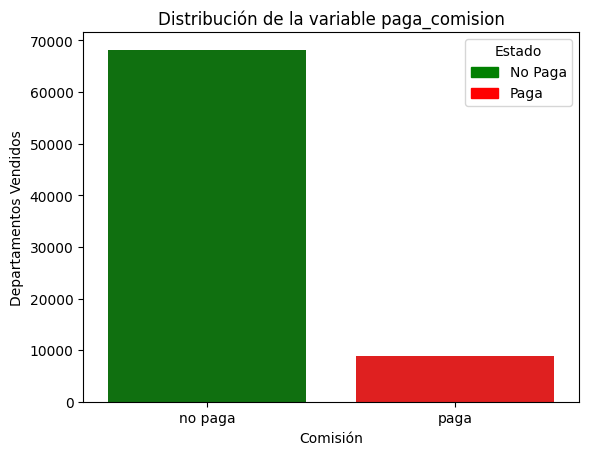

In [95]:
sns.countplot(x='paga_comision', hue='paga_comision', data=df_train, palette=['green', 'red'], legend=False)
plt.xlabel('Comisión')
plt.ylabel('Departamentos Vendidos')
plt.title('Distribución de la variable paga_comision')
patch_no_paga = mpatches.Patch(color='green', label='No Paga')
patch_paga = mpatches.Patch(color='red', label='Paga')
plt.legend(handles=[patch_no_paga, patch_paga], title='Estado')
plt.show()

## 2) Análisis por Columna

A continuación, vamos a realizar un análisis más en profundidad sobre cada una de las posibles variables predictoras para entender su distribución y relación con la variable target **paga_comision**.

#### a) Columnas l4, l5 y l6

Vamos a realizar un análisis con más detalle sobre estas columnas sobre los valores posibles que poseen y sobre la cantidad de valores nulos.

Total de registros del dataset

In [96]:
total = len(df_train)
print(total)

76984


##### Columna l4

###### Valores Únicos

In [97]:
conteo_l4 = df_train['l4'].value_counts()
print(conteo_l4)

l4
Nordelta                1062
La Plata                 878
Ramos Mejía              800
Centro                   563
Olivos                   537
                        ... 
Carlos Spegazzini          1
San Carlos                 1
Barrio Santa Clara         1
San Miguel del Monte       1
Santos Tesei               1
Name: count, Length: 286, dtype: int64


###### Porcentaje de valores nulos

Comparamos la cantidad de valores nulos con la cantidad de registros totales del dataset.

In [98]:
nulos_l4 = df_train['l4'].isnull().sum()
print(f"{(nulos_l4 / total * 100):.2f}%")

80.81%


##### Columna l5

###### Valores Únicos

In [99]:
conteo_l5 = df_train['l5'].value_counts()
print(conteo_l5)

l5
BarrioPortezuelo             65
Barrio El Golf               44
Islas del Canal              18
Barrio El Yacht               7
Barrio Barrancas del Lago     4
QBay Yacht                    4
Enyoi                         4
Barrio Lagos del Golf 1       3
Barrio Lagos del Golf 2       3
Barrio Las Caletas            3
Barrio Los Alisos             2
Barrio La Alameda             2
Name: count, dtype: int64


###### Porcentaje de valores nulos

Comparamos la cantidad de valores nulos con la cantidad de registros totales del dataset.

In [100]:
nulos_l5 = df_train['l5'].isnull().sum()
print(f"{(nulos_l5 / total * 100):.2f}%")

99.79%


##### Columna l6

###### Porcentaje de valores nulos

Comparamos la cantidad de valores nulos con la cantidad de registros totales del dataset.

In [101]:
nulos_l6 = df_train['l6'].isnull().sum()
print(f"{(nulos_l6 / total * 100):.2f}%")

100.00%


Al ver que estas columnas tienen la gran cantidad de sus registros (o todos) en valores nulos, eliminaremos estas columnas para su posterior aplicación en un modelo.

#### b) Columna Latitud

##### Gráfico de Distribución

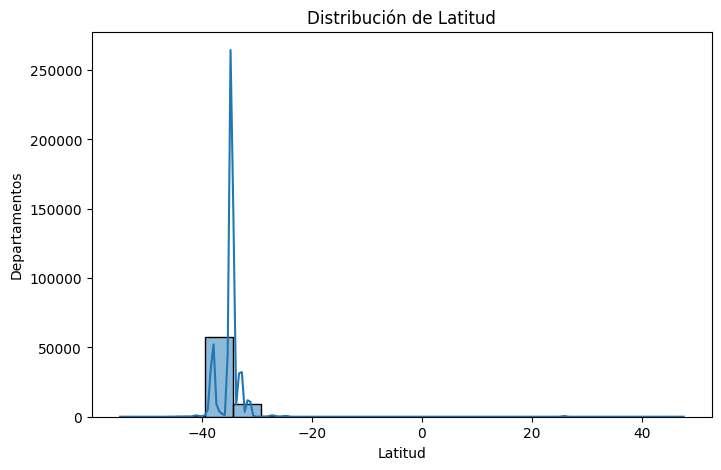

In [102]:
plt.figure(figsize=(8,5))
sns.histplot(df_train['lat'], bins=20, kde=True)
plt.title('Distribución de Latitud')
plt.xlabel('Latitud')
plt.ylabel('Departamentos')
plt.show()

Podemos ver que la variable `Latitud` tiene más registros de entre -40 y -30 aproximadamente. Esto se debe a que estos valores corresponden al país de Argentina.

##### Boxplot

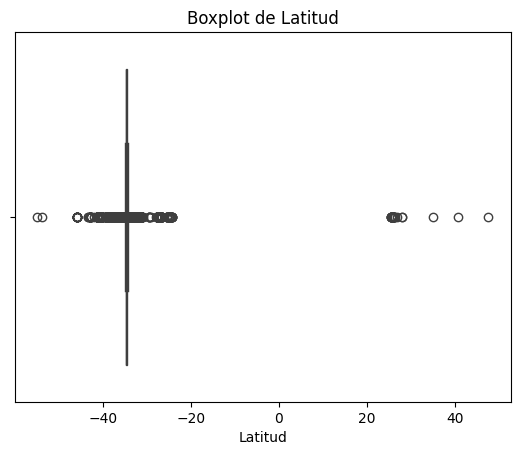

In [103]:
sns.boxplot(x=df_train['lat'])
plt.title('Boxplot de Latitud')
plt.xlabel('Latitud')
plt.show()

Observamos que existen registros con valores outliers en esta columna:
* Outliers Positivos: Tenemos latitudes del valor entre el rango de [20, 50] aproximadamente que corresponden a dichos valores.
* Outliers Negativos: Observamos valores aproximadamente de latitud -50.

Con esto podemos determinar que probablemente existan departamentos vendidos en otros países además de Argentina.

En él [Anexo 1](https://colab.research.google.com/drive/1cDkm02JR3bkgwn7sS20kFvAfq8o1POML#scrollTo=Anexo) se detalla la decisión tomada sobre esta variable predictora, ya que en un principio optamos por elegir una imputación en base a la ubicación, pero finalmente decidimos descartarla.

#### c) Columna Longitud

##### Gráfico de Distribución

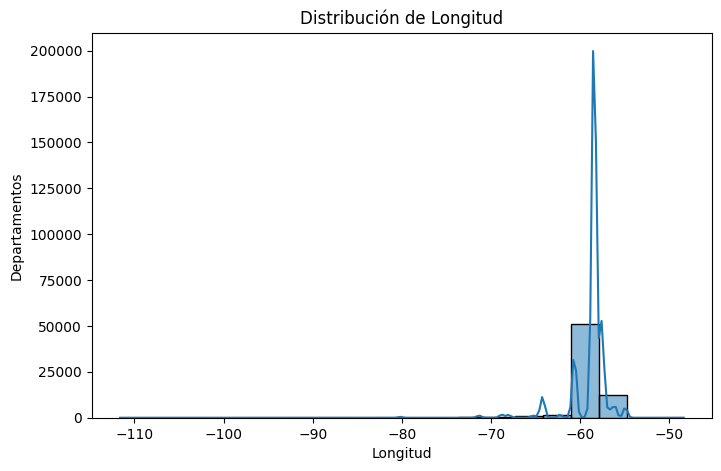

In [104]:
plt.figure(figsize=(8,5))
sns.histplot(df_train['lon'], bins=20, kde=True)
plt.title('Distribución de Longitud')
plt.xlabel('Longitud')
plt.ylabel('Departamentos')
plt.show()

Podemos ver que la variable `Longitud` tiene más registros de entre -65 y -55 aproximadamente. Esto se debe a que estos valores corresponden al país de Argentina.

##### Boxplot

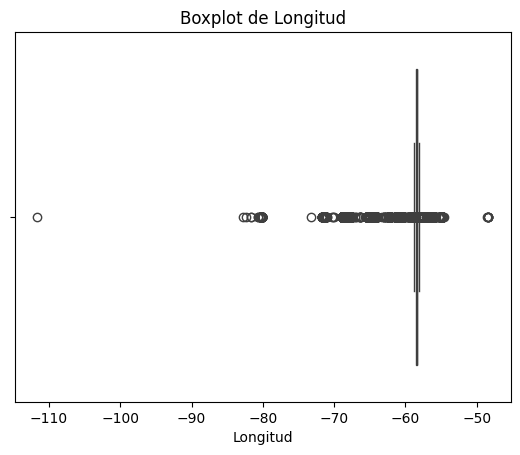

In [105]:
sns.boxplot(x=df_train['lon'])
plt.title('Boxplot de Longitud')
plt.xlabel('Longitud')
plt.show()

Idém columna Latitud: En él [Anexo 1](https://colab.research.google.com/drive/1cDkm02JR3bkgwn7sS20kFvAfq8o1POML#scrollTo=Anexo) se detalla la decisión tomada sobre esta variable predictora, ya que en un principio optamos por elegir una imputación en base a la ubicación, pero finalmente decidimos descartarla.

#### d) Columna l3

##### Valores Únicos

In [106]:
conteo_l3 = df_train['l3'].value_counts()
print(conteo_l3)

l3
Mar del Plata                      9735
Rosario                            7402
Palermo                            4559
Belgrano                           2842
Almagro                            2353
                                   ... 
Vaqueros                              1
La Falda                              1
Luque                                 1
Villa Ciudad Parque Los Reartes       1
Villa Mercedes                        1
Name: count, Length: 294, dtype: int64


##### Countplot general

Al ser demasiados valores únicos, solo vamos a quedarnos con las localidades / partidos que aparecen más en el dataset.

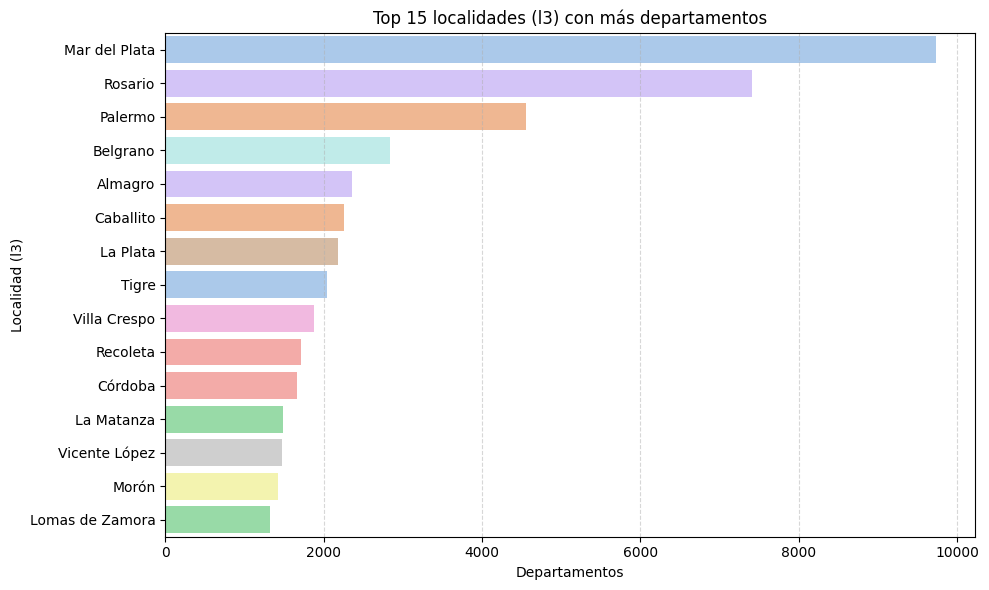

In [107]:
top15_l3 = df_train['l3'].value_counts().head(15).index
df_top15 = df_train[df_train['l3'].isin(top15_l3)]
plt.figure(figsize=(10,6))
sns.countplot(
    y='l3',
    data=df_top15,
    order=top15_l3,
    hue='l3',
    palette='pastel',
    legend=False
)
plt.title('Top 15 localidades (l3) con más departamentos')
plt.xlabel('Departamentos')
plt.ylabel('Localidad (l3)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### Countplot por target (pago_comision)

Realizamos el mismo countplot anterior, pero esta vez segmentando por la variable target para ver si algún departamento tiene mayor proporción de casos con comisión paga o no.

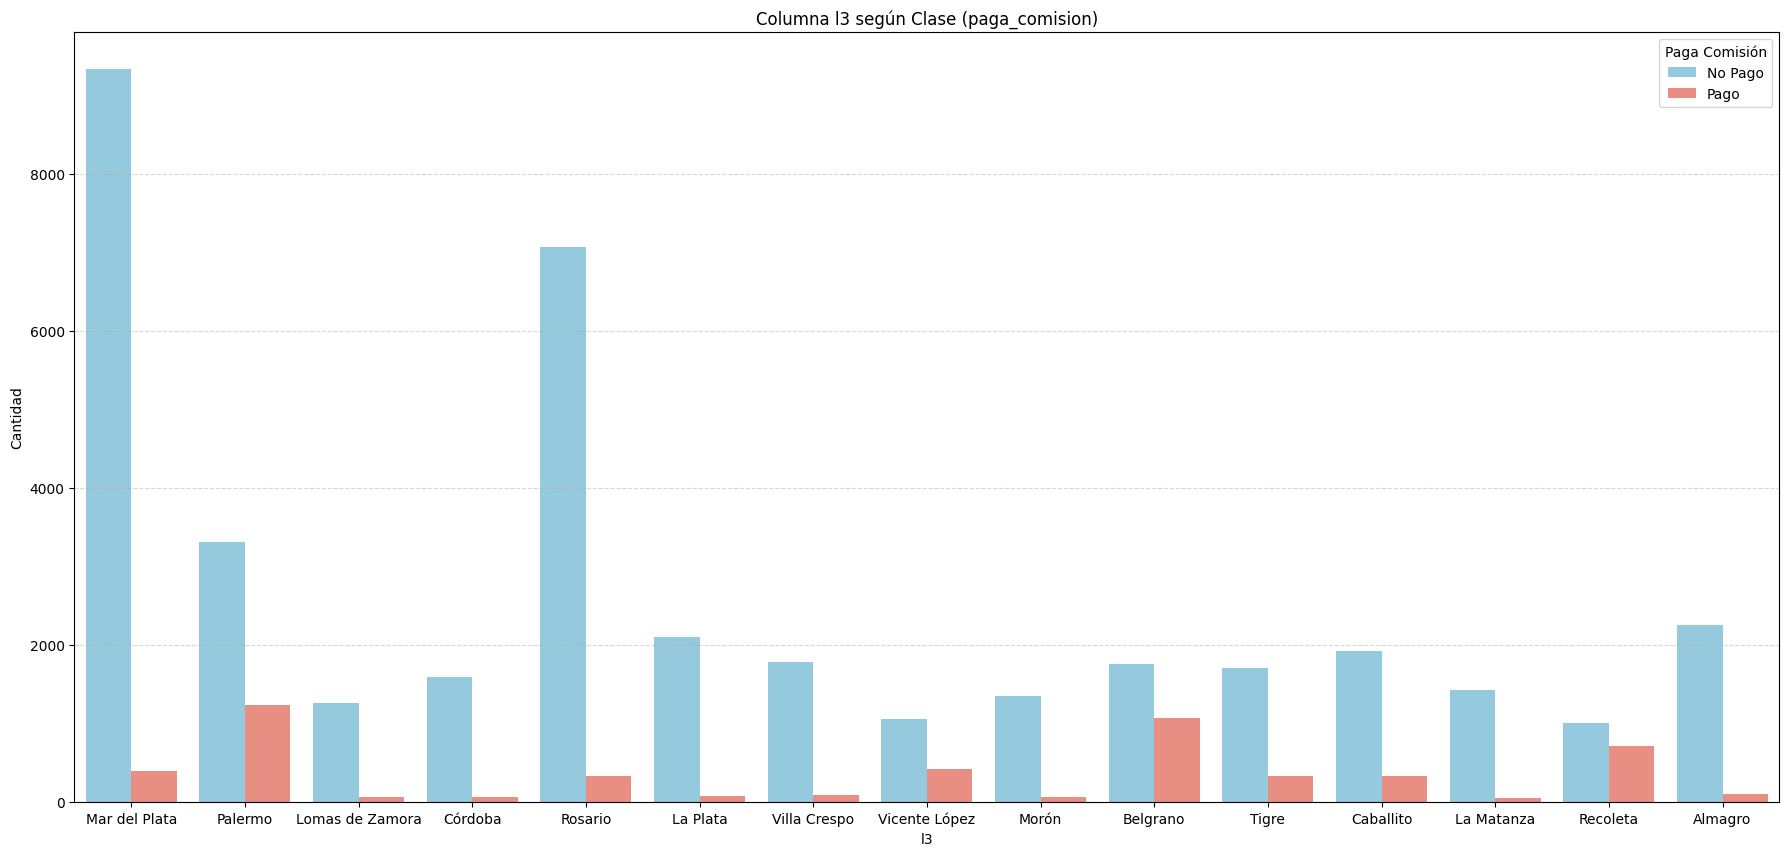

In [108]:
plt.figure(figsize=(22,10))
sns.countplot(x='l3', hue='paga_comision', data=df_top15, palette=['skyblue','salmon'])
plt.title('Columna l3 según Clase (paga_comision)')
plt.xlabel('l3')
plt.ylabel('Cantidad')
plt.legend(title='Paga Comisión', labels=['No Pago','Pago'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Existen algunas localidades las cuales no presentan la misma proporcion entre comision paga o no del departamento, como vimos en el grafico general. Por lo que dependiendo la localidad, puede haber localidades en donde hay mas departamentos en los que se pague la comision que en otros. Por lo que esta tendencia, la analizaremos a futuro.

In [109]:
print(df_train['l3'].isnull().sum())

4498


En esta columna vamos a aplicar una estrategia de imputación de valores nulos, la cual consiste aplicar un valor 'Sin Localidad' a estos registros.

Mas adelante, deberemos realizar una codificación de esta variable no numérica.

#### e) Columna Price Period

##### Valores Únicos

In [110]:
conteo_price_period = df_train['price_period'].value_counts()
print(conteo_price_period)

price_period
Mensual    25755
Name: count, dtype: int64


##### Porcentaje de valores nulos

Comparamos la cantidad de valores nulos con la cantidad de registros totales del dataset.

In [111]:
nulos_price_period = df_train["price_period"].isnull().sum()
print(f"{(nulos_price_period / total * 100):.2f}%")

66.54%


Observamos que hay más de un 66.54% de cantidad de valores nulos de esta columna. La estrategia que decidimos es eliminar la misma, no solo por la cantidad, sino porque también observamos como único valor existente "Mensual" (periodo para realizar el pago del departamento), lo cual consideramos innecesario para aplicarlo a un posterior modelo.

#### f) Columna Rooms

##### Gráfico de Distribución

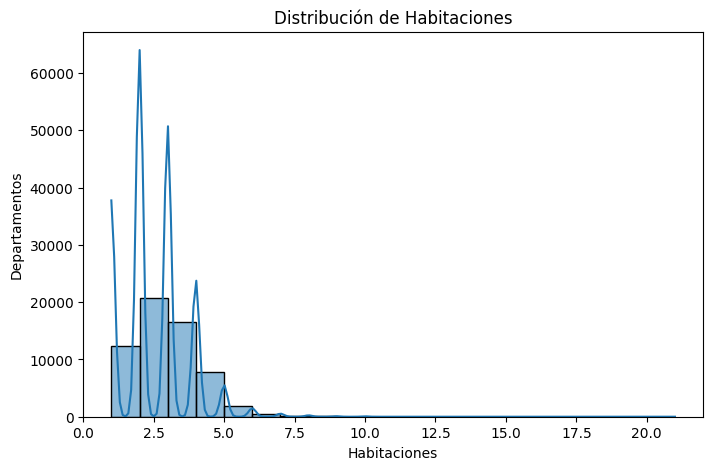

In [112]:
plt.figure(figsize=(8,5))
sns.histplot(df_train['rooms'], bins=20, kde=True)
plt.title('Distribución de Habitaciones')
plt.xlabel('Habitaciones')
plt.ylabel('Departamentos')
plt.show()

Podemos ver que la gran mayoría de departamentos tienen entre 2 y 5 habitaciones.

##### Gráfico de Distribución por target (pago_comision)

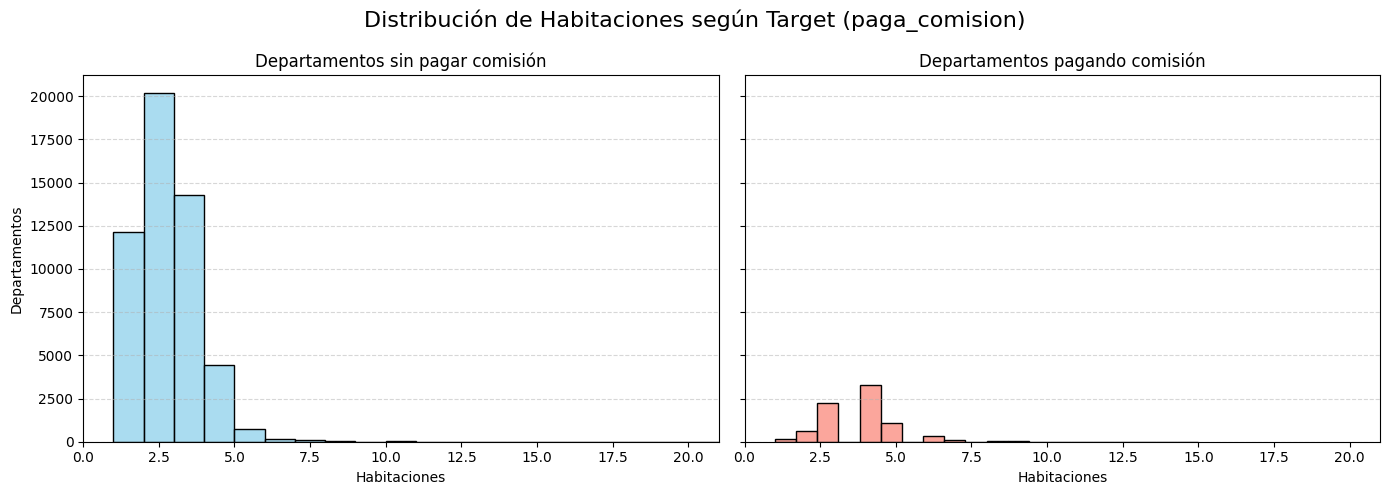

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(data=df_train[df_train['paga_comision'] == 'no paga'], x='rooms', bins=20, color='skyblue', alpha=0.7, ax=axes[0])
axes[0].set_title('Departamentos sin pagar comisión')
axes[0].set_xlabel('Habitaciones')
axes[0].set_ylabel('Departamentos')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_xlim(0, df_train['rooms'].max())

sns.histplot(data=df_train[df_train['paga_comision'] == 'paga'], x='rooms', bins=20, color='salmon', alpha=0.7, ax=axes[1])
axes[1].set_title('Departamentos pagando comisión')
axes[1].set_xlabel('Habitaciones')
axes[1].set_ylabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_xlim(0, df_train['rooms'].max())

plt.suptitle('Distribución de Habitaciones según Target (paga_comision)', fontsize=16)
plt.tight_layout()
plt.show()

En estos últimos gráficos podemos ver que departamentos que tienen 3 habitaciones +-1 son los departamentos más propensos a pagar la comisión. 

##### Boxplot

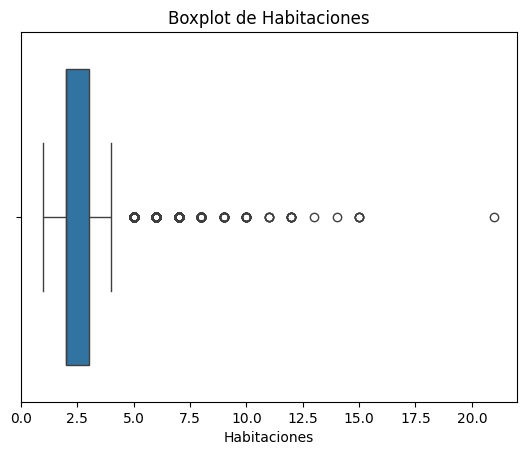

In [114]:
sns.boxplot(x=df_train['rooms'])
plt.title('Boxplot de Habitaciones')
plt.xlabel('Habitaciones')
plt.show()

Con este gráfico observamos outliers en esta columna, habiendo departamentos con más de 5 habitaciones (e incluso algún departamento con más de 20 habitaciones).

##### Boxplot por target (pago_comision)

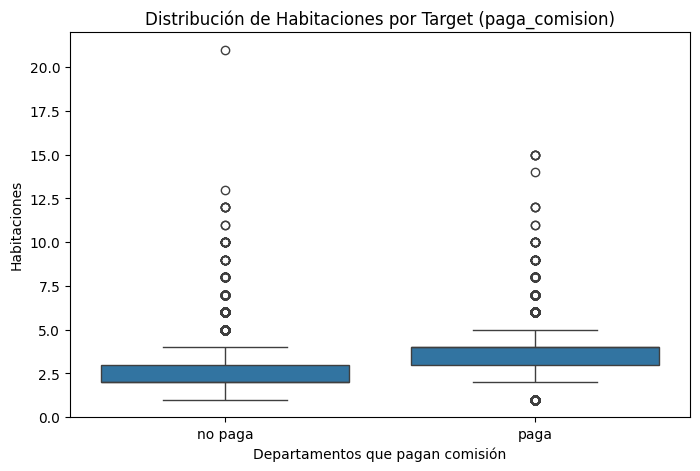

In [115]:
plt.figure(figsize=(8,5))
sns.boxplot(x='paga_comision', y='rooms', data=df_train)
plt.title('Distribución de Habitaciones por Target (paga_comision)')
plt.xlabel('Departamentos que pagan comisión')
plt.ylabel('Habitaciones')
plt.show()

##### Gráfico de Densidad por target (pago_comision)

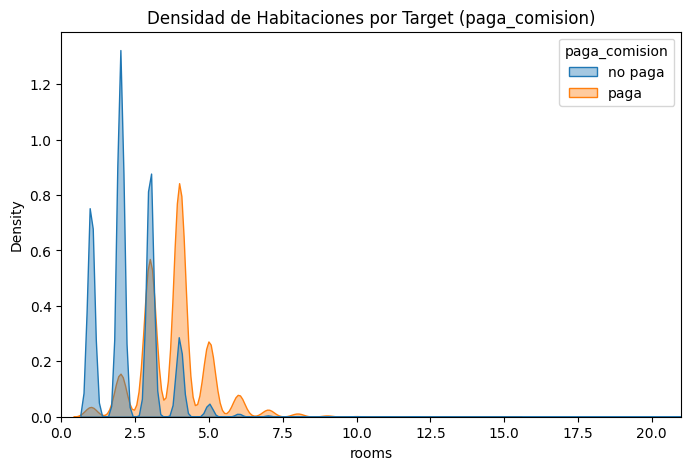

In [116]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_train, x='rooms', hue='paga_comision', fill=True, common_norm=False, alpha=0.4)
plt.title('Densidad de Habitaciones por Target (paga_comision)')
plt.xlim(0, df_train['rooms'].max())
plt.show()

##### Porcentaje de valores nulos

Comparamos la cantidad de valores nulos con la cantidad de registros totales del dataset.

In [117]:
nulos_rooms = df_train["rooms"].isnull().sum()
print(f"{(nulos_rooms / total * 100):.2f}%")

22.10%


Para esta columna, al ser poco su porcentaje de valores nulos, decidimos aplicar la imputación tanto de valores nulos como de outliers aplicando el valor promedio, siendo este valor aproximadamente entre 2 y 3 habitaciones por departamento.

#### g) Columna Bedrooms

##### Gráfico de Distribución

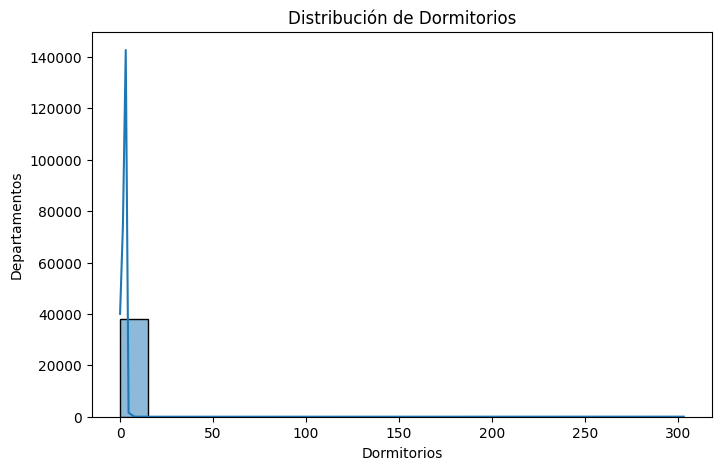

In [118]:
plt.figure(figsize=(8,5))
sns.histplot(df_train['bedrooms'], bins=20, kde=True)
plt.title('Distribución de Dormitorios')
plt.xlabel('Dormitorios')
plt.ylabel('Departamentos')
plt.show()

##### Boxplot

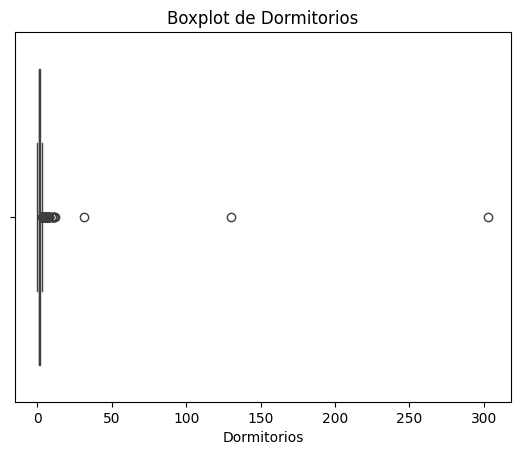

In [119]:
sns.boxplot(x=df_train['bedrooms'])
plt.title('Boxplot de Dormitorios')
plt.xlabel('Dormitorios')
plt.show()

Con este gráfico observamos outliers en esta columna, habiendo departamentos con más de 100 dormitorios (e incluso algún departamento con más de 300 dormitorios). Esto claramente debe ser algún error en los registros del dataset.

##### Porcentaje de valores nulos

Comparamos la cantidad de valores nulos con la cantidad de registros totales del dataset.

In [120]:
nulos_bedrooms = df_train["bedrooms"].isnull().sum()
print(f"{(nulos_bedrooms / total * 100):.2f}%")

50.58%


Para esta columna, decidimos aplicar la imputación tanto de valores nulos como de outliers aplicando el promedio, siendo este valor aproximadamente entre 1 y 2 dormitorios por departamento.

#### h) Columna Bathrooms

##### Boxplot

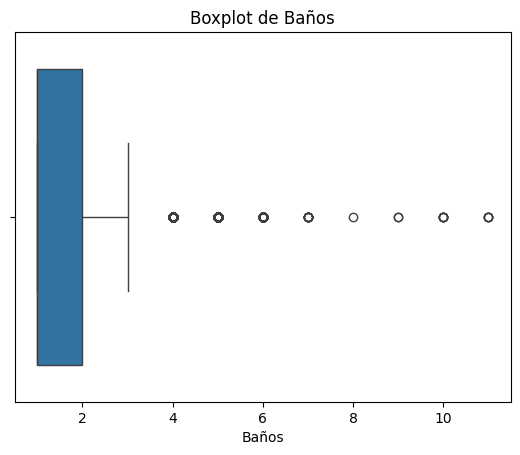

In [121]:
sns.boxplot(x=df_train['bathrooms'])
plt.title('Boxplot de Baños')
plt.xlabel('Baños')
plt.show()

Con este gráfico observamos outliers en esta columna, habiendo departamentos con más de 10 baños.

##### Porcentaje de valores nulos

Comparamos la cantidad de valores nulos con la cantidad de registros totales del dataset.

In [122]:
nulos_bathrooms = df_train["bathrooms"].isnull().sum()
print(f"{(nulos_bathrooms / total * 100):.2f}%")

6.70%


Para esta columna, decidimos aplicar la imputación tanto de valores nulos como de outliers aplicando el promedio, siendo este valor aproximadamente entre 1 y 2 baños por departamento.

#### i) Columna Surface Covered

##### Boxplot

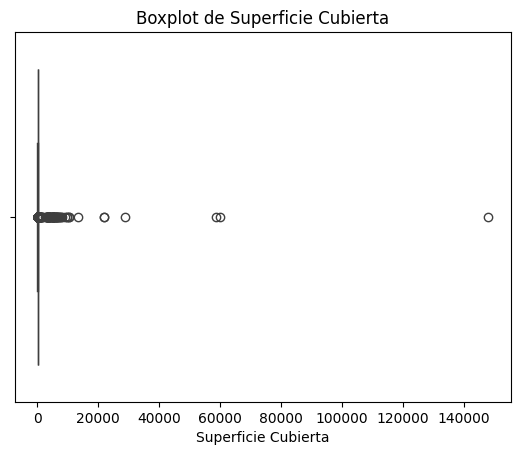

In [123]:
sns.boxplot(x=df_train['surface_covered'])
plt.title('Boxplot de Superficie Cubierta')
plt.xlabel('Superficie Cubierta')
plt.show()

##### Gráfico de Densidad

<Axes: title={'center': 'surface_covered'}, xlabel='surface_covered', ylabel='Density'>

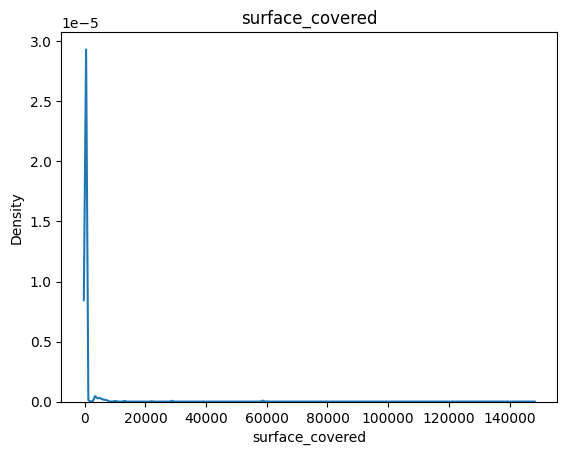

In [124]:
plt.title('surface_covered')
sns.kdeplot(df_train['surface_covered'], fill=False)

##### Porcentaje de valores nulos

Comparamos la cantidad de valores nulos con la cantidad de registros totales del dataset.

In [125]:
nulos_surface_covered = df_train["surface_covered"].isnull().sum()
print(f"{(nulos_surface_covered / total * 100):.2f}%")

40.61%


Para esta columna, decidimos aplicar la imputación tanto de valores nulos como de outliers aplicando el promedio, siendo este valor aproximadamente entre un rango de 40 y 70 m^2 por departamento.

#### j) Análisis de la columna Surface Total

##### Boxplot

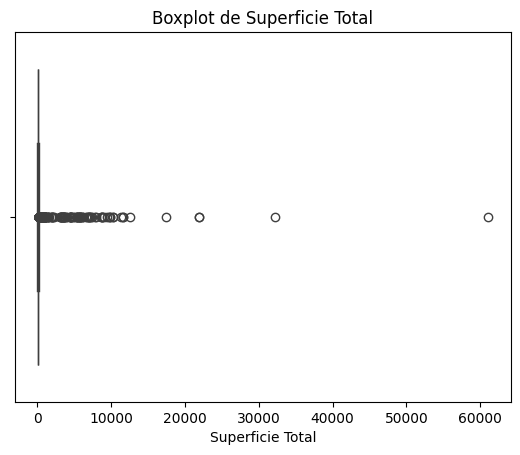

In [126]:
sns.boxplot(x=df_train['surface_total'])
plt.title('Boxplot de Superficie Total')
plt.xlabel('Superficie Total')
plt.show()

##### Gráfico de Densidad

<Axes: title={'center': 'surface_total'}, xlabel='surface_total', ylabel='Density'>

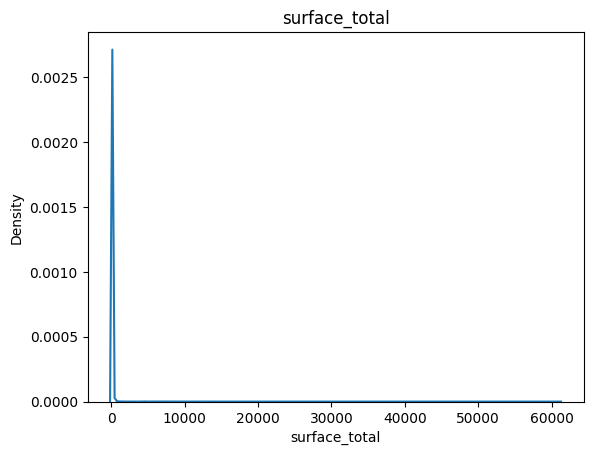

In [127]:
plt.title('surface_total')
sns.kdeplot(df_train['surface_total'], fill=False)

##### Porcentaje de valores nulos

Comparamos la cantidad de valores nulos con la cantidad de registros totales del dataset.

In [128]:
nulos_surface_covered = df_train["surface_total"].isnull().sum()
print(f"{(nulos_surface_covered / total * 100):.2f}%")

44.08%


Para esta columna, decidimos aplicar la imputación tanto de valores nulos como de outliers aplicando el promedio, siendo este valor aproximadamente entre un rango de 45 y 78 metros cuadrados por departamento.

### Matriz de Correlación

La variable target está definida con valores de **paga** y **no paga**. Convertimos los valores de esta columna a valores numéricos, siendo **1** el departamento que paga comisión y **0** el departamento que no paga comisión.

In [129]:
df_train['paga_comision'] = np.where(df_train['paga_comision'] == 'paga', 1, 0)

Eliminamos columna l6 únicamente para graficar la matriz ya que todos sus valores son nulos y a pesar de eso aparecía como numérica.

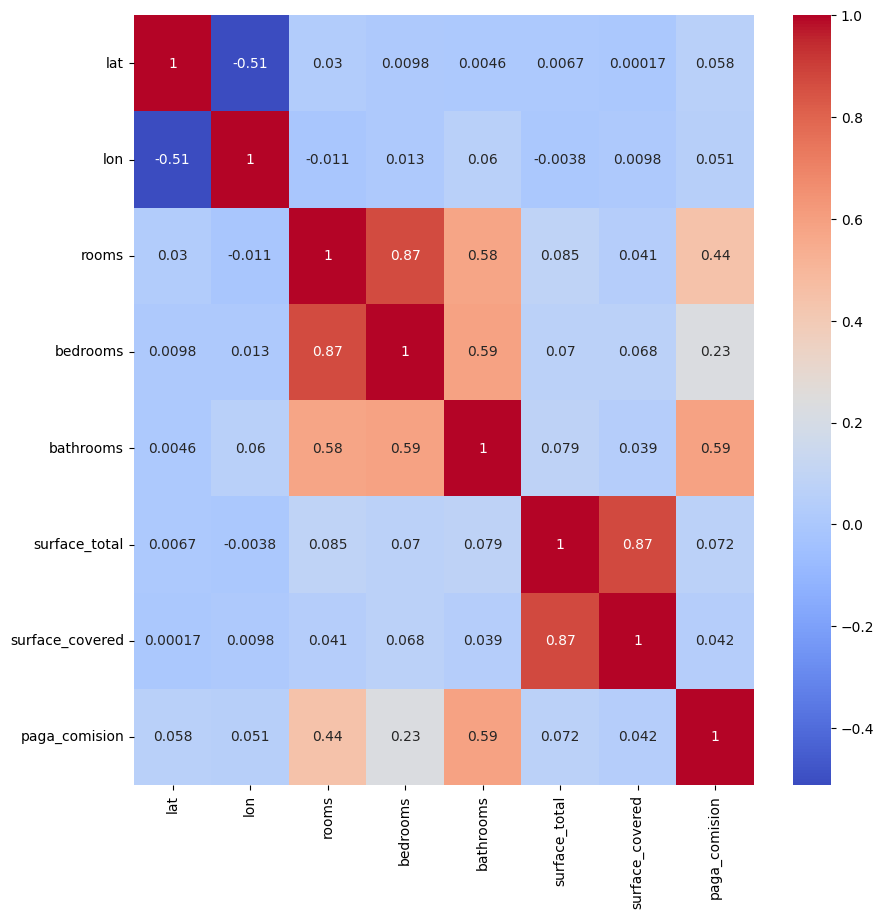

In [130]:
df_numericas = df_train.select_dtypes(include='number')
df_numericas = df_numericas.drop(columns=['l6'])
corr = df_numericas.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [131]:
df_train_corr = df_train.select_dtypes(include='number').corr()[['paga_comision']] * 100
df_train_corr = df_train_corr.drop(index=['paga_comision', 'l6']).sort_values(['paga_comision'], ascending=False)
df_train_corr

,paga_comision
bathrooms,59.034643
rooms,44.156005
bedrooms,23.057084
surface_total,7.213406
lat,5.800865
lon,5.145455
surface_covered,4.176674


Podemos ver que las variables `bathrooms` y `surface_total` se encuentran fuertemente correlacionadas. Entre el resto de variables predictoras no se aprecia ninguna correlación relevante.

## 3) Separación entre Test y Train

Realizamos la separación antes de realizar cualquier otra transformación para evitar fuga de datos.

In [132]:
x_target = df_train.drop(['paga_comision'], axis=1)
y_target = df_train['paga_comision']
X_train, X_test, y_train, y_test = train_test_split(x_target, y_target, test_size=0.3, stratify = y_target, random_state=42)

Realizamos la separación entre **train** y **test** sin filtrar ninguna columna extra. La seleccion de features la realizaremos adentro del pipeline.

## 4) Declaración de Pipelines

### Definición de Clases

En base a lo analizado previamente declaramos las clases que utilizaremos en el pipeline.

#### Imputador Simple (Nulos)

Se aplican a las columnas `rooms`, `bedrooms`, `bathrooms`, `surface_covered` y `surface_total` los valores nulos por la mediana.

In [133]:
class ColSimpleImputer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.imputers = {}

    def fit(self, X, y=None):
        X = X.copy()
        for col in self.columns:
            self.imputers[col] = X[col].median()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].fillna(self.imputers[col])
        return X

#### Imputador Outliers

Se aplican a las columnas `rooms`, `bedrooms`, `bathrooms`, `surface_covered` y `surface_total` los valores atípicos por la media.

In [134]:
class ColOutliersImputer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.medias_ = {}
        self.limites_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        for c in self.columns:
            Q1 = X[c].quantile(0.25)
            Q3 = X[c].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            self.limites_[c] = {'lower': lower, 'upper': upper}
            mean_filtrada = X[(X[c] >= lower) & (X[c] <= upper)][c].mean()
            self.medias_[c] = mean_filtrada
        return self

    def transform(self, X):
        X = X.copy()
        for c in self.columns:
            lower = self.limites_[c]['lower']
            upper = self.limites_[c]['upper']
            X[c] = np.where((X[c] < lower) | (X[c] > upper), self.medias_[c], X[c])
        return X

#### Eliminar Features

En una primera aproximación, se aplican a las columnas `ad_type`, `start_date`, `end_date`, `created_on`, `lat`, `lon`, `l4`, `l5`, `l6`, `price_period` y `title`.

In [135]:
class EliminarFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop, errors='ignore')

#### Codificación de L3 (Localidades)

Únicamente este imputador se aplica a los valores nulos de la columna `l3`, que representa a la Localidad / Estado del país.

In [136]:
def imputar_l3(df):
    df = df.copy()
    df['l3'] = df['l3'].fillna('Sin Localidad')
    return df

In [137]:
imputar_l3_transformer = FunctionTransformer(imputar_l3)

#### One Hot Encoder

Se aplican a las columnas `l1`, `l2` y `l3`, siendo países, provincias y localidades respectivamente.

In [138]:
class ColOneHot(BaseEstimator, TransformerMixin):
    def __init__(self, encoder=None, columns=[]):
        super().__init__()
        self.encoder = encoder
        self.columns = columns

    def fit(self, X, y=None):
        self.encoder.fit(X[self.columns])
        return self

    def get_feature_names_out(self):
        return self.encoder.get_feature_names_out()

    def  transform(self, X):
        Xc = X.copy()
        Xc.loc[:, self.encoder.get_feature_names_out()] = self.encoder.transform(Xc.loc[:,self.columns])
        Xc.drop(self.columns, axis=1, inplace=True)
        return Xc

#### Feature Engineering

Aprovechamos las columnas de fecha inicio (`start_date`) y fecha fin (`end_date`) para agregar una nueva columna al dataset llamada `is_active`, el cual determina si el departamento se encuentra activo, y para ello en la columna `end_date`, vimos fecha con el año **9999**, asumiendo que esta fecha es considerada que no tiene fecha fin, ese departamento se encontraría activo.

In [139]:
class FeatureEngineerFechas(BaseEstimator, TransformerMixin):
    def __init__(self, start_col='start_date', end_col='end_date'):
        self.start_col = start_col
        self.end_col = end_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()
        X_transformed['is_active'] = (X_transformed[self.end_col].astype(str).str.startswith('9999').astype(int))
        X_transformed[self.start_col] = pd.to_datetime(X_transformed[self.start_col], format='%Y-%m-%d', errors='coerce')
        X_transformed[self.end_col] = pd.to_datetime(X_transformed[self.end_col], format='%Y-%m-%d', errors='coerce')
        X_transformed['duration_days'] = (X_transformed[self.end_col] - X_transformed[self.start_col]).dt.days
        X_transformed['duration_days'] = (X_transformed['duration_days'].fillna(0).astype(int))
        X_transformed.loc[X_transformed['duration_days'] < 0, 'duration_days'] = 0
        return X_transformed

## 5) Aplicación del Pipeline

Aplicamos un pipeline con todas las imputaciones que se aclaración en la sección **2) Análisis por Columna**, aplicando las clases imputadoras en los steps.

In [140]:
pipeline_preprocesamiento = Pipeline(steps=[
    ('feature_engineer_fechas', FeatureEngineerFechas(start_col='start_date', end_col='end_date')),
    ('eliminar_features', EliminarFeatures(columns_to_drop=['ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l4', 'l5', 'l6', 'price_period', 'title'])),
    ('imputador_simple_nulos', ColSimpleImputer(columns=['rooms', 'bedrooms', 'bathrooms', 'surface_covered', 'surface_total'])),
    ('imputador_outliers', ColOutliersImputer(columns=['rooms', 'bedrooms', 'bathrooms', 'surface_covered', 'surface_total'])),
    ('imputador_localidades', imputar_l3_transformer),
    ('one_hot', ColOneHot(encoder=OneHotEncoder(sparse_output=False, drop=None, dtype=int, handle_unknown='ignore'), columns=['l1','l2','l3'])),
])

In [141]:
pipeline_preprocesamiento.fit(X_train, y_train)
X_train_preprocesado = pipeline_preprocesamiento.transform(X_train)

### Clasificador

Para una primera aplicación, utilizamos el modelo **Random Forest Classifier**, ajustado con los siguientes hiperparámetros.

In [142]:
random_forest_model = RandomForestClassifier(
    bootstrap=True,
    class_weight='balanced',
    criterion='entropy',
    max_depth=15,
    max_features='sqrt',
    min_samples_leaf=10,
    min_samples_split=20,
    n_estimators=312,
    n_jobs=1,
    random_state=42,
)

El parámetro **class_weight='balanced'** instruye al algoritmo a compensar el desbalance de clases asignando un mayor peso (penalización) a los errores cometidos sobre las muestras de la clase minoritaria ('paga'). Es decir, el parámetro le dice al algoritmo Random Forest que ajuste automáticamente el peso de las muestras inversamente a su frecuencia de clase en los datos de entrenamiento.

### Pipeline Clasificador

Construimos un pipeline que integra tanto las etapas de preprocesamiento de los datos como el modelo de clasificación seleccionado.

In [143]:
pipeline = Pipeline(steps=[
    ('preprocesamiento', pipeline_preprocesamiento),
    ('clasificador', random_forest_model)
])

In [144]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocesamiento', ...), ('clasificador', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('feature_engineer_fechas', ...), ('eliminar_features', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,start_col,'start_date'
,end_col,'end_date'
,columns_to_drop,"['ad_type', 'start_date', ...]"


### Resultados del Pipeline

In [145]:
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['No Paga', 'Paga']))

Accuracy: 0.8663
              precision    recall  f1-score   support

     No Paga       0.98      0.86      0.92     20464
        Paga       0.46      0.88      0.60      2632

    accuracy                           0.87     23096
   macro avg       0.72      0.87      0.76     23096
weighted avg       0.92      0.87      0.88     23096



El modelo obtuvo un 87 % de exactitud global, con un desempeño diferenciado entre clases. Para la clase “no paga comisión”, alcanzó una precisión del 0.98 y un recall del 0.86, lo que indica que clasifica correctamente casi todos los casos negativos con pocos falsos positivos.

En cambio, para la clase “paga comisión”, logró una precisión del 0.46 y un recall del 0.88, es decir, detecta la mayoría de los casos positivos, aunque con cierta pérdida de precisión. En conjunto, el modelo muestra un buen equilibrio entre sensibilidad y precisión, generaliza adecuadamente y prioriza correctamente la detección de los departamentos que pagan comisión, que son los más relevantes para el negocio.

### Función de Ganancia

Aplicamos la función de ganancia que se pide el enunciado, con el objetivo de determinar si la predicción consigue departamentos que paguen la comisión.

In [146]:
def calcular_ganancia(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    ganancia_por_aciertos = tp * 100
    perdida_por_fallos = fp * 50
    ganancia_total = ganancia_por_aciertos - perdida_por_fallos
    return ganancia_total

ganancia = calcular_ganancia(y_test, y_pred)
print(f"Ganancia en el conjunto de prueba: USD {ganancia:,.0f}")

Ganancia en el conjunto de prueba: USD 93,000


Podemos observar que la ganancia es de USD 93.000. Lo esperable es que sea mayor a USD 120.000, por lo que vamos a realizar un análisis más a detalle de los resultados y aplicar alguna técnica que ayude al modelo.

### Matriz de Confusión

Text(0.5, 1.0, 'Matriz de Confusión - Random Forest')

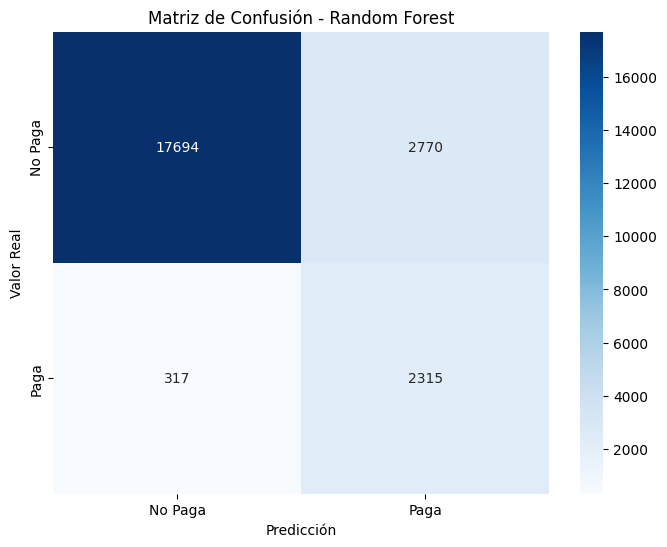

In [147]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Paga', 'Paga'],
            yticklabels=['No Paga', 'Paga'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Random Forest')

## 6) Oversampling

Inicialmente realizamos un gráfico el cual nos ayudó a visualizar la cantidad de departamentos totales que pagan la comisión contra los que no la pagan.

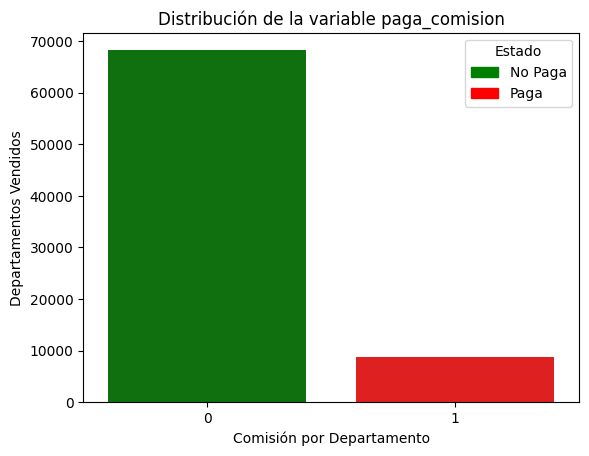

In [148]:
sns.countplot(x='paga_comision', hue='paga_comision', data=df_train, palette=['green', 'red'], legend=False)
plt.xlabel('Comisión por Departamento')
plt.ylabel('Departamentos Vendidos')
plt.title('Distribución de la variable paga_comision')
patch_no_paga = mpatches.Patch(color='green', label='No Paga')
patch_paga = mpatches.Patch(color='red', label='Paga')
plt.legend(handles=[patch_no_paga, patch_paga], title='Estado')
plt.show()

Con esta cantidad desbalanceada intuimos que el modelo va a tender a un comportamiento de predecir por un departamento que no pago (y que posiblemente tenga que pagar la comisión). En definitiva, aplicamos la técnica de Oversampling para obtener más muestras de departamentos que pagan comisión y poder observar si se presenta algún comportamiento distinto.

Debemos aplicar Oversampling antes del Split Train/Test, ya que así evitamos **data leakage**:
* Las muestras sintéticas del train pueden tener "gemelos" en test.
* El modelo ve información del conjunto de test durante entrenamiento.
* Las métricas están infladas artificialmente.

In [149]:
df_train_over = df_train.copy()
X = df_train_over[df_train_over.columns.drop('paga_comision')]
y = df_train_over['paga_comision']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

Primero aplicamos el pipeline de preprocesamiento ya que si se aplica primero la técnica, las muestras sintéticas heredan los mismos problemas que los datos originales.

In [150]:
pipeline_preprocesamiento_oversampling = Pipeline(steps=[
    ('feature_engineer_fechas', FeatureEngineerFechas(start_col='start_date', end_col='end_date')),
    ('eliminar_features', EliminarFeatures(columns_to_drop=['ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l4', 'l5', 'l6', 'price_period', 'title'])),
    ('imputador_simple_nulos', ColSimpleImputer(columns=['rooms', 'bedrooms', 'bathrooms', 'surface_covered', 'surface_total'])),
    ('imputador_outliers', ColOutliersImputer(columns=['rooms', 'bedrooms', 'bathrooms', 'surface_covered', 'surface_total'])),
    ("imputar_l3", imputar_l3_transformer),
    ("one_hot", ColOneHot(encoder=OneHotEncoder(sparse_output=False, drop=None, dtype=int, handle_unknown='ignore'), columns=['l1','l2','l3'])),
])

In [151]:
X_train = pipeline_preprocesamiento_oversampling.fit_transform(X_train)
X_test = pipeline_preprocesamiento_oversampling.transform(X_test)

Aplicamos la técnica luego de preprocesar.

In [152]:
ros = RandomOverSampler(random_state=42, sampling_strategy=0.25)
X_train, y_train = ros.fit_resample(X_train, y_train)
df_ros = pd.concat([X_train, y_train], axis=1)

Aplicamos el grafico para visualizar las nuevas muestras.

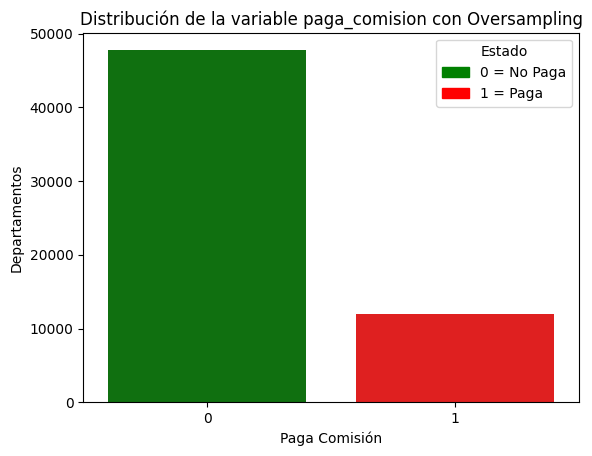

In [153]:
sns.countplot(x='paga_comision', hue='paga_comision', data=df_ros, palette=['green', 'red'], legend=False)
plt.xlabel('Paga Comisión')
plt.ylabel('Departamentos')
plt.title('Distribución de la variable paga_comision con Oversampling')
patch_no_paga = mpatches.Patch(color='green', label='0 = No Paga')
patch_paga = mpatches.Patch(color='red', label='1 = Paga')
plt.legend(handles=[patch_no_paga, patch_paga], title='Estado')
plt.show()

In [154]:
pagos = (df_ros['paga_comision'] == 1).sum()
print(pagos)

11937


Podemos observar que el Oversampling devolvió en nuestro dataset unos 11.937 registros con departamentos que pagan la comisión, logrando que el dataset se encuentre más balanceado. Pasamos a aplicar el procesamiento previo de Pipelines, pero ahora se la aplicamos luego de realizar la técnica.

Ahora aplicamos el modelo con hiperparámetros balanceados

In [155]:
random_forest_oversampling = RandomForestClassifier(
    bootstrap=True,
    criterion='entropy',
    class_weight=None,
    max_depth=15,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    n_estimators=312,
    n_jobs=-1,
    random_state=42,
)

In [156]:
random_forest_oversampling.fit(X_train, y_train)

,n_estimators,312
,criterion,'entropy'
,max_depth,15
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [157]:
y_pred = random_forest_oversampling.predict(X_test)

### Resultados

In [158]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9321094561828888

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     20464
           1       0.74      0.62      0.67      2632

    accuracy                           0.93     23096
   macro avg       0.85      0.80      0.82     23096
weighted avg       0.93      0.93      0.93     23096



### Función de Ganancia

In [159]:
ganancia_oversampling = calcular_ganancia(y_test, y_pred)
print(f"\nGanancia en test: USD {ganancia_oversampling:,.0f}")


Ganancia en test: USD 134,600


Podemos ver que la ganancia aumento y ahora es de USD 142.650. Este resultado seria el esperado ya que superamos los USD 120.000 que se esperaba.

### Matriz de Confusión

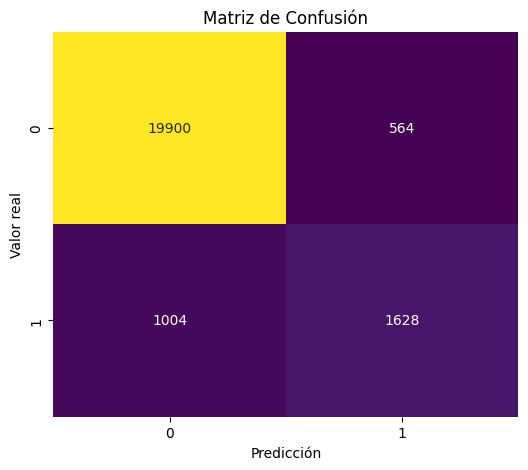

In [160]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión')
plt.show()

## 7) Optimización

En esta sección vamos a explicar como llegamos a la selección del modelo final, la consifguración de sus hiperparametros y la selección de features.

### Grid Search

Ejecutamos Grid Search con los siguientes parámetros:
* Modelos evaluados: LogisticRegression, DecisionTree, RandomForest, KNN, NaiveBayes
* Scoring: Precision (por el costo asimétrico de los errores)
* Cross-Validation: StratifiedKFold(n_splits=2)

In [161]:
X_grid_search = df_train.drop('paga_comision', axis=1)
y_grid_search = df_train['paga_comision']
X_train_grid_search, X_test_grid_search, y_train_grid_search, y_test_grid_search = train_test_split(X_grid_search, y_grid_search, test_size=0.3, stratify=y_grid_search, random_state=42)

In [162]:
pipeline_preprocesamiento_grid_search = Pipeline(steps=[
    ('feature_engineer_fechas', FeatureEngineerFechas(start_col='start_date', end_col='end_date')),
    ('eliminar_features', EliminarFeatures(columns_to_drop=['ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l4', 'l5', 'l6', 'price_period', 'title'])),
    ('imputador_simple_nulos', ColSimpleImputer(columns=['rooms', 'bedrooms', 'bathrooms', 'surface_covered', 'surface_total', 'is_active', 'duration_days'])),
    ('imputador_outliers', ColOutliersImputer(columns=['rooms', 'bedrooms', 'bathrooms', 'surface_covered', 'surface_total'])),
    ("imputar_l3", imputar_l3_transformer),
    ("one_hot", ColOneHot(encoder=OneHotEncoder(sparse_output=False, drop=None, dtype=int, handle_unknown='ignore'), columns=['l1','l2','l3'])),
])

Para el scoring del Grid Search, seleccionamos la métrica precision dado que buscamos minimizar los falsos positivos y aumentar los verdaderos positivos en nuestro modelo.

**Aclaración**: Se redujo el rango de búsqueda para que la ejecución de la celda se realice en un tiempo razonable.

In [163]:
cachedir = mkdtemp()

modelos = {
    "LogisticRegression": Pipeline([
        ('pre', pipeline_preprocesamiento_grid_search),
        ('clf', LogisticRegression())
    ], memory=cachedir),
    "DecisionTree": Pipeline([
        ('pre',pipeline_preprocesamiento_grid_search),
        ('clf', DecisionTreeClassifier())
    ], memory=cachedir),
    "RandomForest": Pipeline([
        ('pre',pipeline_preprocesamiento_grid_search),
        ('clf', RandomForestClassifier())
    ], memory=cachedir),
    "KNN": Pipeline([
        ('pre',pipeline_preprocesamiento_grid_search),
        ('clf', KNeighborsClassifier())
    ], memory=cachedir),
    "NaiveBayes": Pipeline([
        ('pre', pipeline_preprocesamiento_grid_search),
        ('clf', GaussianNB())
    ], memory=cachedir)
}

param_grids = {
    'LogisticRegression': {
        'clf__C': [0.1, 1],
        'clf__penalty': ['l1', 'l2'],
        'clf__solver': ['liblinear']
    },
    'DecisionTree': {
        'clf__max_depth': [3, 5, 10],
        'clf__max_leaf_nodes': [50, 200],
        'clf__min_samples_split': [2, 5, 10]
    },
    'RandomForest': {
        'clf__class_weight': [None, 'balanced'],
        'clf__max_depth': [5, 10, None],
        'clf__max_leaf_nodes': [50, 200],
        'clf__min_samples_split': [2, 5, 10],
        'clf__n_estimators': [100, 200],
    },
    'KNN': {
        'clf__metric': ['euclidean', 'manhattan'],
        'clf__n_neighbors': [5, 11, 21]
    },
    'NaiveBayes': {
        'clf__var_smoothing': [1e-9, 1e-8, 1e-7]
    }
}

grid_results = {}

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

for name, pipeline in modelos.items():
    grid_pre = GridSearchCV(
        cv=cv,
        estimator=pipeline,
        n_jobs=1,
        param_grid=param_grids[name],
        scoring='precision',
        verbose=1
    )

    grid_pre.fit(X_train_grid_search, y_train_grid_search)
    grid_results[name] = grid_pre
    
shutil.rmtree(cachedir)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Fitting 2 folds for each of 18 candidates, totalling 36 fits
Fitting 2 folds for each of 72 candidates, totalling 144 fits
Fitting 2 folds for each of 6 candidates, totalling 12 fits
Fitting 2 folds for each of 3 candidates, totalling 6 fits


In [164]:
for name, grid in grid_results.items():
    print(f"\n{'='*50}")
    print(f"Modelo: {name}")
    print(f"{'='*50}")
    best_model = grid.best_estimator_
    y_pred_grid_search = best_model.predict(X_test_grid_search)
    ganancia = calcular_ganancia(y_test_grid_search, y_pred_grid_search)
    print(f"Mejores parámetros: {grid.best_params_}")
    print(f"Mejor score (CV): {grid.best_score_:.4f}")
    print(f"Accuracy (test): {accuracy_score(y_test_grid_search, y_pred_grid_search):.4f}")
    print(f"Ganancia: USD {ganancia:,.0f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_grid_search, y_pred_grid_search, target_names=['No Paga', 'Paga']))


Modelo: LogisticRegression
Mejores parámetros: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Mejor score (CV): 0.7381
Accuracy (test): 0.9179
Ganancia: USD 95,550

Classification Report:
              precision    recall  f1-score   support

     No Paga       0.93      0.98      0.95     20464
        Paga       0.73      0.45      0.55      2632

    accuracy                           0.92     23096
   macro avg       0.83      0.71      0.75     23096
weighted avg       0.91      0.92      0.91     23096


Modelo: DecisionTree
Mejores parámetros: {'clf__max_depth': 5, 'clf__max_leaf_nodes': 200, 'clf__min_samples_split': 2}
Mejor score (CV): 0.7896
Accuracy (test): 0.9207
Ganancia: USD 93,050

Classification Report:
              precision    recall  f1-score   support

     No Paga       0.93      0.99      0.96     20464
        Paga       0.80      0.40      0.54      2632

    accuracy                           0.92     23096
   macro avg       0.87      0.7

## 8) Entregable

### Departamentos Predecir

In [169]:
df_predecir = pd.read_csv('dptos_predecir.csv')
df_predecir = df_predecir.set_index('id')

### Aplicar preprocesamiento

In [172]:
df_predecir_prep = pipeline_preprocesamiento_oversampling.transform(df_predecir)
df_predecir_prep = df_predecir_prep.drop(columns=['paga_comision'])

### Predicciones con el modelo entrenado

In [173]:
predicciones = random_forest_oversampling.predict(df_predecir_prep)

### Filtrar solo casos que pagan comisión

In [174]:
df_predecir['paga_comision'] = predicciones
df_entrega = df_predecir[df_predecir['paga_comision'] == 1].copy()

### Preparar archivo de entrega

In [175]:
df_entrega_final = df_entrega.reset_index()[['id']]
df_entrega_final['paga_comision'] = 'paga'

### Guardar archivo

In [176]:
df_entrega_final.to_csv('dptos_entrega.csv', index=False)

In [177]:
print(f"✅ Archivo generado: dptos_entrega.csv")
print(f"📊 Total de departamentos que pagarán comisión: {len(df_entrega_final)}")
print(f"💰 Ganancia proyectada (estimada): USD {len(df_entrega_final) * 100:,.0f}")
df_entrega_final.head()

✅ Archivo generado: dptos_entrega.csv
📊 Total de departamentos que pagarán comisión: 5511
💰 Ganancia proyectada (estimada): USD 551,100


,id,paga_comision
0,Utxs29/Xs0bbj3SuNc23cQ==,paga
1,gYKVX4fyx7XyBtarir4cEg==,paga
2,Yq173dwehCQGxOEviTOhug==,paga
3,RWjSFixkfK58tGdOkHzQKw==,paga
4,i3s0RnXV9kMdw50AD4V8gQ==,paga


# Anexo

## Imputación de columnas Latitud (lat) y Longitud (lon)

### Columna Latitud

En una primera aplicacion, tomamos la siguiente estrategia: existen departamentos que se encuentran en lugares distintos, como es el caso de Estados Unidos, Brasil o Uruguay.

Como la gran mayoria de departamentos se encuentran en provincias de Argentina, estos registros son considerados outliers en el boxplot general. Es por esto que vamos a tomar los pares pais (l1) y provincia (l2) para luego imputar por la media de cada uno de estos grupos.

In [ ]:
'''conteo_pares = df_train.groupby(['l1', 'l2']).size().reset_index(name='cantidad')
print(conteo_pares)'''

"conteo_pares = df_train.groupby(['l1', 'l2']).size().reset_index(name='cantidad')\nprint(conteo_pares)"

In [ ]:
'''df_train = df_train.copy()
df_train['lat'] = df_train['lat'].fillna(df_train.groupby(['l1', 'l2'])['lat'].transform('mean'))'''

"df_train = df_train.copy()\ndf_train['lat'] = df_train['lat'].fillna(df_train.groupby(['l1', 'l2'])['lat'].transform('mean'))"

Verificamos si se realizo la imputación de valores nulos correctamente.

In [ ]:
'''print(df_train['lat'].isnull().sum())'''

"print(df_train['lat'].isnull().sum())"

### Columna Longitud

Para este caso, quisimos aplicar la misma estrategia para valores nulos que para la columna Longitud, por lo tanto vamos a separamos los pares Pais - Provincia / Estado e imputamos por la media.

In [ ]:
'''df_train = df_train.copy()
df_train['lon'] = df_train['lon'].fillna(df_train.groupby(['l1', 'l2'])['lon'].transform('mean'))'''

"df_train = df_train.copy()\ndf_train['lon'] = df_train['lon'].fillna(df_train.groupby(['l1', 'l2'])['lon'].transform('mean'))"

Verificamos si se realizo la imputación de valores nulos correctamente.

In [ ]:
'''print(df_train['lon'].isnull().sum())'''

"print(df_train['lon'].isnull().sum())"

### Conclusión Final

Finalmente decidimos optar por eliminar estas columnas ya que consideramos que no aportan valor alguno para la predicción de comisiones pagas.